In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_parquet("cleaned_vgsales.parquet")
df

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51,8.0,322,Nintendo,Everyone
1,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,<NA>,NaN,<NA>,Unknown,Unknown
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73,8.3,709,Nintendo,Everyone
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73,8.0,192,Nintendo,Everyone
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,<NA>,NaN,<NA>,Unknown,Unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16714,Samurai Warriors: Sanada Maru,PS3,2016,Action,Tecmo Koei,0.00,0.00,0.01,0.00,0.01,NaN,<NA>,NaN,<NA>,Unknown,Unknown
16715,LMA Manager 2007,X360,2006,Sports,Codemasters,0.00,0.01,0.00,0.00,0.01,NaN,<NA>,NaN,<NA>,Unknown,Unknown
16716,Haitaka no Psychedelica,PSV,2016,Adventure,Idea Factory,0.00,0.00,0.01,0.00,0.01,NaN,<NA>,NaN,<NA>,Unknown,Unknown
16717,Spirits & Spells,GBA,2003,Platform,Wanadoo,0.01,0.00,0.00,0.00,0.01,NaN,<NA>,NaN,<NA>,Unknown,Unknown


In [3]:
count = [
    'Platform',
    'Genre',
    'Publisher'
]

for col in count:
    print(f"\n{col}:")
    print(df[col].value_counts())
    


Platform:
Platform
PS2     2161
DS      2152
PS3     1331
Wii     1320
X360    1262
PSP     1209
PS      1197
PC       974
XB       824
GBA      822
GC       556
3DS      520
PSV      432
PS4      393
N64      319
XOne     247
SNES     239
SAT      173
WiiU     147
2600     133
NES       98
GB        98
DC        52
GEN       29
NG        12
SCD        6
WS         6
3DO        3
TG16       2
GG         1
PCFX       1
Name: count, dtype: int64

Genre:
Genre
Action          3370
Sports          2348
Misc            1750
Role-Playing    1500
Shooter         1323
Adventure       1303
Racing          1249
Platform         888
Simulation       874
Fighting         849
Strategy         683
Puzzle           580
Unknown            2
Name: count, dtype: int64

Publisher:
Publisher
Electronic Arts                 1356
Activision                       985
Namco Bandai Games               939
Ubisoft                          933
Konami Digital Entertainment     834
                               

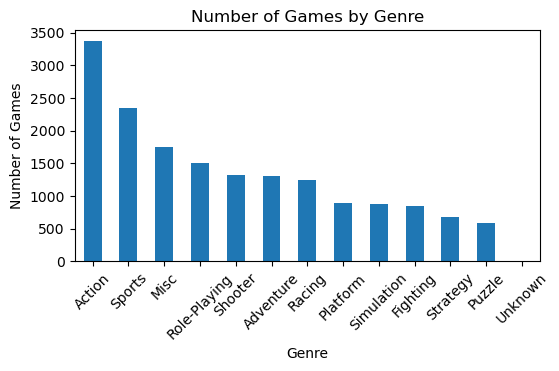

In [11]:
# genres having most video games

genre_count = df['Genre'].value_counts()

genre_count.plot(kind="bar", figsize=(6, 3))

plt.title("Number of Games by Genre")
plt.xlabel("Genre")
plt.ylabel("Number of Games")
plt.xticks(rotation=45)
plt.show()

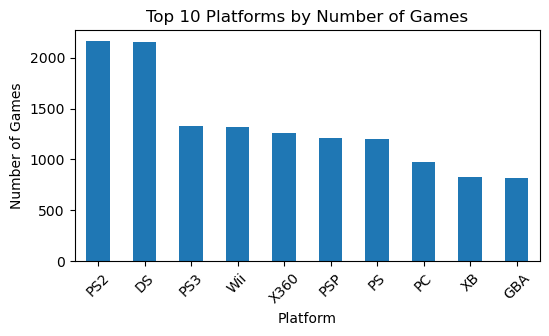

In [12]:
top_platform = df['Platform'].value_counts()

top_platform.head(10).plot(kind = "bar", figsize = (6, 3))
plt.title("Top 10 Platforms by Number of Games")
plt.xlabel("Platform")
plt.ylabel("Number of Games")
plt.xticks(rotation=45)
plt.show()

In [13]:
genre_sales = df.groupby("Genre")["Global_Sales"].sum().sort_values(ascending=False)

genre_sales

Genre
Action          1745.27
Sports          1332.00
Shooter         1052.94
Role-Playing     934.40
Platform         828.08
Misc             803.18
Racing           728.90
Fighting         447.48
Simulation       390.42
Puzzle           243.02
Adventure        237.69
Strategy         174.50
Unknown            2.42
Name: Global_Sales, dtype: float64

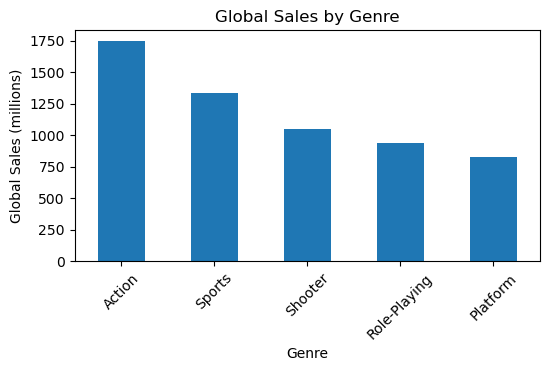

In [14]:
genre_sales.head(5).plot(kind="bar", figsize=(6, 3))

plt.title("Global Sales by Genre")
plt.xlabel("Genre")
plt.ylabel("Global Sales (millions)")
plt.xticks(rotation=45)
plt.show()

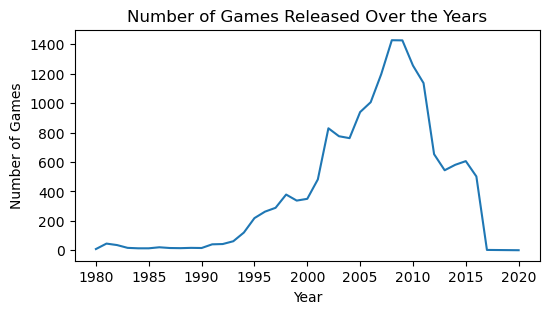

In [16]:
yearly_releases = df["Year_of_Release"].value_counts().sort_index()

yearly_releases.plot(figsize=(6, 3))

plt.title("Number of Games Released Over the Years")
plt.xlabel("Year")
plt.ylabel("Number of Games")
plt.show()

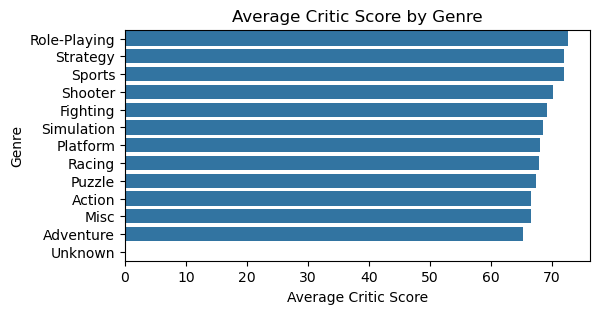

In [23]:
# genres having highest average critic_score

genre_score = df.groupby('Genre')['Critic_Score'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize = (6,3))

sns.barplot(
    data=genre_score,
    x="Critic_Score",
    y="Genre"
)

plt.title("Average Critic Score by Genre")
plt.xlabel("Average Critic Score")
plt.ylabel("Genre")

plt.show()

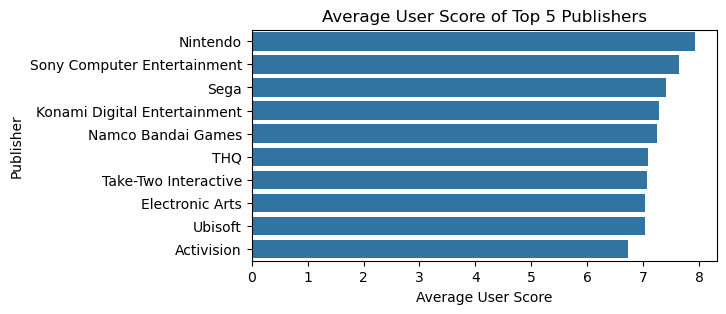

In [27]:
# Question: Which major publishers have the highest average user scores?

top_publishers = df["Publisher"].value_counts().head(10).index

publisher_scores = (
    df[df["Publisher"].isin(top_publishers)]
    .groupby("Publisher")["User_Score"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(6, 3))

sns.barplot(
    x=publisher_scores.values,
    y=publisher_scores.index
)

plt.title("Average User Score of Top 5 Publishers")
plt.xlabel("Average User Score")
plt.ylabel("Publisher")

plt.show()

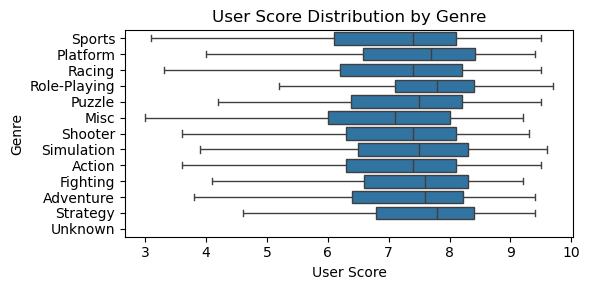

In [30]:
plt.figure(figsize=(6, 3))

sns.boxplot(
    data=df,
    x="User_Score",
    y="Genre",
    showfliers=False
)

plt.title("User Score Distribution by Genre")
plt.xlabel("User Score")
plt.ylabel("Genre")

plt.tight_layout()
plt.show()

In [31]:
df.to_csv("cleaned_data.csv", index = False)